# Protein Groups Analysis – Adipocytes

## Overview

This notebook performs comparative analysis of **protein group identifications** across different processing pipelines (e.g., *Standard* vs *SBM 3*) for mouse adipocytes datasets.  

It focuses on:

- Filtering and cleaning protein group outputs
- Comparing dataset-specific protein identifications
- Quantifying intensity distributions
- Identifying uniquely detected proteins
- Performing Gene Ontology (GO) enrichment summaries
- Exploring subcellular localization
- Visualizing overlaps using UpSet plots


## Input Data

### 1. Protein Group Files
Tab-delimited `proteinGroups.txt` files from different workflows:

- `SBM 3`
- `Standard`

These are loaded from:
'''../adipocytes/DATASET/txt/proteinGroups.txt'''


### The notebook produces:

* Bar charts of protein counts per dataset
* Rank-intensity scatter plots
* Intensity distribution histograms
* GO enrichment bar plots
* Counts of unique proteins and genes with subcellular localization summaries


The plots are shown in Figure 6, with some extra plots beeing shown here. 

In [40]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from upsetplot import UpSet
import textwrap

import re
from collections import Counter

plt.rcParams["font.family"] = "Arial" 

from matplotlib.colors import LinearSegmentedColormap

%load_ext autoreload
from protein_inference import * 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
color_map = {
    '0': '#ffbc42',
    'VM': '#ffbc42',
    'SBM 0': '#ffbc42',
    'sbm_o_4': '#2ca02c', 
    'st':    '#d81159', 
    'Standard':    '#d81159', 
    'Unique Standard':    '#d81159',
    'sbm_3': '#73d2de', 
    'SBM 3': '#73d2de', 
    'MQ SBM 3': '#73d2de', 
    'MQ SBM 3 Percolator': '#b7e8ee', 
    'sbm3': '#73d2de',
    'Unique SBM 3': '#73d2de',
    'sbm_8': '#218380',
    'sbm8': '#218380',
    'SBM 8': '#218380', 
    'MSFragger': '#60435f', 
    'MSFragger 9nl Percolator': '#60435f', 
    'Unique MSFragger': '#60435f'
}

custom_order = ['Standard', 'SBM 3']

# Importing the data

In [3]:
fig_dir = '/Users/hmt128/figures/mq_dev_analysis_figs/diff_sets/adipocytes_review/'
#root_dir = '/Volumes/Groupdir/SUN-CPR-proteomics_mln/CL/adipocytes' 
f_path = "/Volumes/Groupdir/SUN-CPR-proteomics_mln/CL/uniprot/MOUSE.fasta"

pg_sbm3 = "/Volumes/Groupdir/SUN-CPR-proteomics_mln/CL/adipocytes_review/SBM 3/combined/txt/proteinGroups.txt"
pg_st = "/Volumes/Groupdir/SUN-CPR-proteomics_mln/CL/adipocytes_review/Standard/combined/txt/proteinGroups.txt"

comp_file = '/Volumes/Groupdir/SUN-CPR-proteomics_mln/CL/compartments/mouse_compartment_integrated_full_filtered.tsv'


In [ ]:
root_dir = '../adipocytes' 
f_path = "../MOUSE.fasta"

pg_sbm3 = "../adipocytes/SBM 3/txt/proteinGroups.txt"
pg_st = "../adipocytes/Standard/txt/proteinGroups.txt"


comp_file = '..compartments/mouse_compartment_integrated_full_filtered.tsv'

In [4]:
def process_dataframe(file_path, site_column, dataset_name):
        """
    Load and clean a MaxQuant proteinGroups file for SUMO site analysis.

    Removes potential contaminants and reverse hits, filters for valid
    modification site entries, standardizes the SUMO site column name,
    and adds a dataset label.

    Parameters
    ----------
    file_path : str
        Path to the tab-delimited proteinGroups.txt file.
    site_column : str
        Name of the dataset-specific SUMO site column.
    dataset_name : str
        Label assigned to the dataset (e.g., "Standard", "SBM 3").

    Returns
    -------
    pandas.DataFrame
        Filtered dataframe with standardized
        'SUMO2/3-DVFQQQTGG site positions' and added 'Dataset' column.
    """
    
    df = pd.read_csv(file_path, delimiter="\t")
    df = df[df['Potential contaminant'] != '+']
    df['Reverse'].fillna('-', inplace=True)
    df = df[df['Reverse'] != '+']
    df[site_column].fillna('-', inplace=True)
    df = df[df[site_column] != '-']
        
    df['SUMO2/3-DVFQQQTGG site positions'] = df[site_column]
    df['Dataset'] = dataset_name
    
    return df

df_pg_st = process_dataframe(pg_st, 'st_o_SUMO2/3-DVFQQQTGG site positions', 'Standard')
df_pg_sbm3 = process_dataframe(pg_sbm3, 'SBM_3_o_SUMO2/3-DVFQQQTGG site positions', 'SBM 3')

pg_dfs = pd.concat([df_pg_sbm3, df_pg_st], ignore_index=True)

In [5]:
%autoreload 2

pg_dfs = protein_inference_pg(pg_dfs, species ='mouse') # custom function, look into protein_inference.py for details

/Users/hmt128/miniconda3/lib/python3.11/site-packages/biotite/sequence/io/fasta/convert.py:248: UserWarning: ProteinSequence objects do not support selenocysteine (U), occurrences were substituted by cysteine (C)
  warnings.warn(


In [7]:
df_sbm_3 = pg_dfs[pg_dfs['Dataset'] == "SBM 3"]
df_st = pg_dfs[pg_dfs['Dataset'] == "Standard"]

In [11]:
print(f"Total SBM 3 proteins: {len(df_sbm_3)}")
print(f"SBM 3 with valid Protein IDs: {df_sbm_3['Protein IDs'].notna().sum()}")
print(f"Unique SBM 3 Protein IDs: {df_sbm_3['Protein IDs'].nunique()}")

print(f"Set size (original): {len(set(df_sbm_3['Protein IDs']) - set(df_st['Protein IDs']))}")

unique_prots = set(df_sbm_3['Gene_name']) - set(df_st['Gene_name'])
len(unique_prots)

Total SBM 3 proteins: 1402
SBM 3 with valid Protein IDs: 1402
Unique SBM 3 Protein IDs: 1402
Set size (original): 300


150

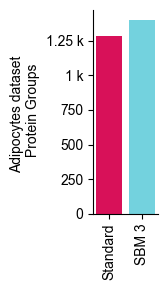

In [18]:
filtered_counts_results = pg_dfs.groupby('Dataset').size()
sorted_counts_pgs = filtered_counts_results.reindex(custom_order)

fig, ax = plt.subplots(figsize=(1.7, 3))

bars = ax.bar(
    sorted_counts_pgs.index, 
    sorted_counts_pgs.values, 
    color=[color_map.get(dataset, 'grey') for dataset in sorted_counts_pgs.index]
)

# Uncomment to display bar values on top
#for bar in bars:
#     height = bar.get_height()
#     ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')

ax.set_xlabel('')
ax.set_ylabel('Adipocytes dataset \n Protein Groups')
ax.set_title('')
ax.set_xticks(range(len(sorted_counts_pgs.index)))
ax.set_xticklabels(sorted_counts_pgs.index, rotation=90)  # Adjust rotation if needed
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())

plt.tight_layout()
file_path = fig_dir + "Protein_groups.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

/Users/hmt128/miniconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_9316/1262234073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sbm_3['Intensity_log2'] = np.log2(df_sbm_3['Intensity'])
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_9316/1262234073.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sbm_3['

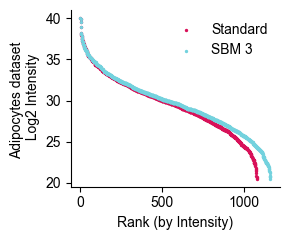

In [19]:
df_sbm_3['Intensity_log2'] = np.log2(df_sbm_3['Intensity'])
df_sbm_3['Rank'] = df_sbm_3['Intensity_log2'].rank(ascending=False)

df_st['Intensity_log2'] = np.log2(df_st['Intensity'])
df_st['Rank'] = df_st['Intensity_log2'].rank(ascending=False)

df_sbm_3 = df_sbm_3[np.isfinite(df_sbm_3['Intensity_log2'])]
df_st = df_st[np.isfinite(df_st['Intensity_log2'])]

fig, ax = plt.subplots(figsize=(3, 2.5))

ax.scatter(df_st['Rank'], df_st['Intensity_log2'], color=color_map["st"], s=2, label="Standard")
ax.scatter(df_sbm_3['Rank'], df_sbm_3['Intensity_log2'], color=color_map["sbm3"], s=2, label="SBM 3")

ax.set_xlabel('Rank (by Intensity)')
ax.set_ylabel('Adipocytes dataset \n Log2 Intensity')
ax.set_title('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.legend(frameon=False)
file_path = fig_dir + "dynamic_range.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

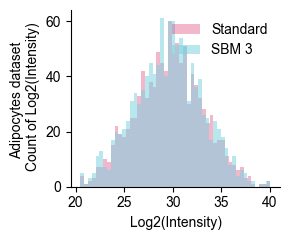

In [20]:
fig, ax = plt.subplots(figsize=(3, 2.5))

ax.hist(df_st['Intensity_log2'], bins=50, color=color_map["st"], alpha=0.3, density=False, label="Standard")
ax.hist(df_sbm_3['Intensity_log2'], bins=50, color=color_map["sbm3"], alpha=0.5, density=False, label="SBM 3")

ax.set_xlabel('Log2(Intensity)')
ax.set_ylabel('Adipocytes dataset \n Count of Log2(Intensity)')
ax.set_title('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(frameon=False) 
plt.tight_layout()

# Save and show the plot
file_path = fig_dir + "log2_intensity_histogram.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

In [21]:
unique_proteins = df_sbm_3.merge(df_st[['Protein IDs']], on='Protein IDs', how='left', indicator=True)
unique_proteins = unique_proteins[unique_proteins['_merge'] == 'left_only'].drop(columns=['_merge'])

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_9316/710838720.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=key_counts.index, x=key_counts.values, palette='mako')
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_9316/710838720.py:21: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


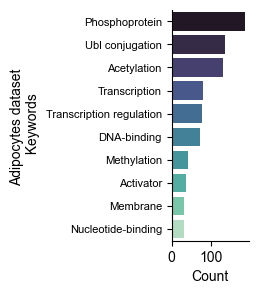

In [23]:
exclude = ["Nucleus", "Reference proteome", "Cytoplasm", "3D-structure", "Repeat", "Direct protein sequencing", "Coiled coil", "Isopeptide bond", "Metal-binding", "Zinc", "Zinc-finger", "Alternative splicing"]

unique_protein_ids = set(df_sbm_3['Protein IDs']) - set(df_st['Protein IDs'])
unique_proteins = df_sbm_3[df_sbm_3['Protein IDs'].isin(unique_protein_ids)]

key_terms = unique_proteins['Keywords'].dropna().str.split(';').explode().str.strip()
key_terms = key_terms[~key_terms.isin(exclude)]

key_counts = key_terms.value_counts().head(10)

wrap_width = 40
key_counts.index = [textwrap.fill(label, wrap_width) for label in key_counts.index]

plt.figure(figsize=(1,3))
sns.barplot(y=key_counts.index, x=key_counts.values, palette='mako')
plt.xlabel("Count")
plt.ylabel("Adipocytes dataset \n Keywords")
plt.yticks(fontsize=8) 
sns.despine(top=True, right=True)
plt.tight_layout()
file_path = fig_dir + "keywords.pdf"
plt.savefig(file_path, transparent=True, bbox_inches='tight')
plt.show()

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_9316/552837227.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=go_counts.index, x=go_counts.values, palette='mako')
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_9316/552837227.py:23: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


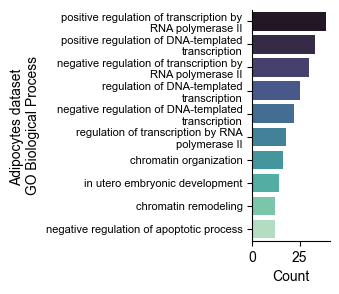

In [24]:
unique_protein_ids = set(df_sbm_3['Protein IDs']) - set(df_st['Protein IDs'])

unique_proteins = df_sbm_3[df_sbm_3['Protein IDs'].isin(unique_protein_ids)]

go_column = 'Gene Ontology (biological process)'
go_terms = unique_proteins[go_column].dropna().str.split(';').explode().str.strip()

go_terms_cleaned = go_terms.str.replace(r'\[.*?\]', '', regex=True).str.strip()

go_counts = go_terms_cleaned.value_counts().head(10)

wrap_width = 40

go_counts.index = [textwrap.fill(label, wrap_width) for label in go_counts.index]

plt.figure(figsize=(1,3))
sns.barplot(y=go_counts.index, x=go_counts.values, palette='mako')
plt.yticks(fontsize=8) 
plt.xlabel("Count")
plt.ylabel("Adipocytes dataset \nGO Biological Process")
sns.despine(top=True, right=True)
plt.tight_layout()
file_path = fig_dir + "bio_processes.pdf"
plt.savefig(file_path, transparent=True, bbox_inches='tight')
plt.show()

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_9316/2777012991.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=go_counts.index, x=go_counts.values, palette='mako')
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_9316/2777012991.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


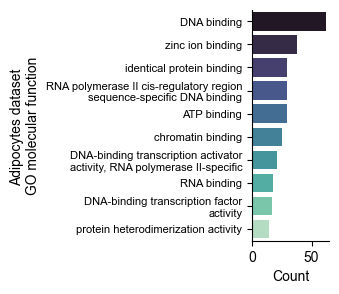

In [25]:
go_column = 'Gene Ontology (molecular function)'
go_terms = unique_proteins[go_column].dropna().str.split(';').explode().str.strip()

go_terms_cleaned = go_terms.str.replace(r'\[.*?\]', '', regex=True).str.strip()
go_counts = go_terms_cleaned.value_counts().head(10)

go_counts.index = [textwrap.fill(label, wrap_width) for label in go_counts.index]

plt.figure(figsize=(1, 3))
sns.barplot(y=go_counts.index, x=go_counts.values, palette='mako')
plt.yticks(fontsize=8) 
plt.xlabel("Count")
plt.ylabel("Adipocytes dataset \nGO molecular function")
#plt.title("Top 10 GO Molecular Function (Unique to SBM 3)")
sns.despine(top=True, right=True)
plt.tight_layout()
file_path = fig_dir + "bio_molfunc.pdf"
plt.savefig(file_path, transparent=True, bbox_inches='tight')
plt.show()

In [31]:
comp = pd.read_csv(comp_file, sep = '\t', header =None)
comp = comp[comp[4] >= 3]

comp[3] = comp[3].str.replace('Cytoskeleton', 'Cytosol').str.replace('Peroxisome', 'Cytosol').str.replace('Lysosome', 'Cytosol').str.replace('Endoplasmic reticulum', 'Cytosol').str.replace('Endosome', 'Cytosol').str.replace('Golgi apparatus', 'Cytosol').str.replace('Mitochondrion', 'Cytosol')

column_rename_map = {
    1: 'Gene_name',
    3: 'Gene Ontology (cellular component)'
}

comp.rename(columns=column_rename_map, inplace=True)

comp = comp.drop_duplicates(subset=['Gene_name', 'Gene Ontology (cellular component)'])

comp_joined = comp.groupby('Gene_name', as_index=False)['Gene Ontology (cellular component)'].apply(lambda x: ', '.join(x)).reset_index(drop=True)
comp_joined['Gene Ontology (cellular component)'] = comp_joined['Gene Ontology (cellular component)'].apply(
    lambda x: ', '.join(
        sorted(x.split(', '), key=lambda y: (y != 'Nucleus', y))
    )
)

In [32]:
pg_dfs_dedup = pg_dfs.drop_duplicates(subset=['Protein IDs', 'Dataset'])

dataset_names = pg_dfs_dedup['Dataset'].unique()
dataset_protein_sets = {
    name: set(pg_dfs_dedup[pg_dfs_dedup['Dataset'] == name]['Protein IDs'].dropna())
    for name in dataset_names
}

all_protein_ids = set().union(*dataset_protein_sets.values())

data = []
for protein_id in all_protein_ids:
    row = [protein_id in dataset_protein_sets[name] for name in dataset_names]
    row.append(protein_id)
    data.append(row)

column_names = list(dataset_protein_sets.keys()) + ['Protein IDs']
df_overlap = pd.DataFrame(data, columns=column_names)

protein_to_gene = (
    pg_dfs_dedup.groupby('Protein IDs')['Gene_name']
    .first()  
    .reset_index()
)
df_overlap = df_overlap.merge(protein_to_gene, on='Protein IDs', how='left')


df_overlap = df_overlap.merge(comp_joined, on='Gene_name', how='left')
df_overlap['Gene Ontology (cellular component)'] = df_overlap['Gene Ontology (cellular component)'].fillna("Unknown")

df_overlap.set_index(column_names[:-1], inplace=True)

In [37]:
categories = df_overlap['Gene Ontology (cellular component)'].dropna().unique().tolist()
categories.sort()
print(categories)

space_colors = {
    'Cytosol': '#1f77b4',
    'Cytosol, Extracellular space': '#5fa9dd',
    'Cytosol, Extracellular space, Plasma membrane': '#94c7ec',
    'Cytosol, Plasma membrane': '#bcdcf5',
    
    'Extracellular space': '#658a4c',
    'Extracellular space, Plasma membrane': '#82ad62',
    'Plasma membrane': '#98c574',
    
    'Nucleus': '#ffba08',
    'Nucleus, Cytosol': '#faa307',
    'Nucleus, Cytosol, Extracellular space': '#e85d04',
    'Nucleus, Cytosol, Extracellular space, Plasma membrane': '#dc2f02',
    'Nucleus, Cytosol, Plasma membrane': '#d00000',
    'Nucleus, Extracellular space': '#9d0208',
    'Nucleus, Extracellular space, Plasma membrane': '#6a040f',
    'Nucleus, Plasma membrane': '#370617',

    'Unknown': '#7f7f7f'
}

['Cytosol', 'Cytosol, Extracellular space', 'Cytosol, Extracellular space, Plasma membrane', 'Cytosol, Plasma membrane', 'Extracellular space', 'Extracellular space, Plasma membrane', 'Nucleus', 'Nucleus, Cytosol', 'Nucleus, Cytosol, Extracellular space', 'Nucleus, Cytosol, Extracellular space, Plasma membrane', 'Nucleus, Cytosol, Plasma membrane', 'Nucleus, Extracellular space', 'Nucleus, Plasma membrane', 'Plasma membrane', 'Unknown']


/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_9316/237278377.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


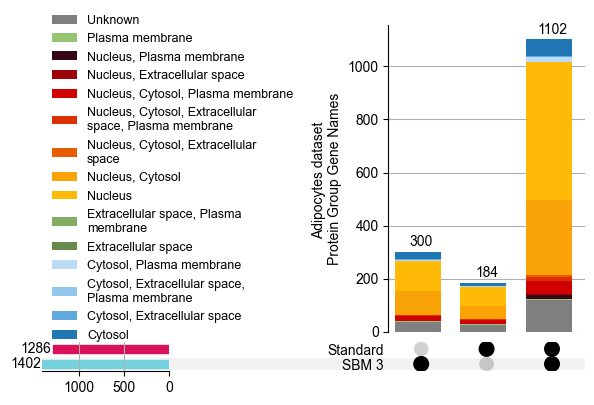

In [41]:
upset = UpSet(
    df_overlap,
    intersection_plot_elements=0, 
    subset_size="count", 
    min_subset_size=20, 
    show_counts=True, 
    element_size = 30, 
)

upset.add_stacked_bars(
    by='Gene Ontology (cellular component)',
    colors=space_colors,
    title='Adipocytes dataset \nProtein Group Gene Names',
    elements=len(space_colors)
)

for category in color_map:
    upset.style_categories(
        [category],
        bar_facecolor=color_map.get(category, 'grey'), 
        bar_edgecolor=None
    )

ax_dict = upset.plot()

fig = plt.gcf() 
fig.set_size_inches(7, 4.5)

for bar in ax_dict['extra0'].patches:
    bar.set_width(0.7) 
    bar.set_x(bar.get_x() - 0.15) 

handles, labels = ax_dict['extra0'].get_legend_handles_labels()

wrapped_labels = ['\n'.join(textwrap.wrap(label, 35)) for label in labels]

ax_dict['extra0'].legend(handles, wrapped_labels, frameon=False,
                         loc='center', bbox_to_anchor=(-1.1, 0.5), fontsize=9)
plt.tight_layout()
plt.gcf().savefig(fig_dir + "upset_plot_gnas.pdf", format="pdf", transparent=True, bbox_inches='tight')
plt.show()